In [117]:
import matplotlib.pyplot as plt
import numpy as np

In [118]:
# 样本特征
data_X = [
    [1.3, 6],
    [3.5, 5],
    [4.2, 2],
    [5, 3.3],
    [2, 9],
    [5, 7.5],
    [7.2, 4],
    [8.1, 8],
    [9, 2.5]]

In [119]:
# 样本标记
data_y = [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7]

In [120]:
# 训练集
X_train = np.array(data_X)
y_train = np.array(data_y)

In [121]:
print(X_train)

[[1.3 6. ]
 [3.5 5. ]
 [4.2 2. ]
 [5.  3.3]
 [2.  9. ]
 [5.  7.5]
 [7.2 4. ]
 [8.1 8. ]
 [9.  2.5]]


In [122]:
print(y_train)

[0.1 0.3 0.5 0.7 0.9 1.1 1.3 1.5 1.7]


In [123]:
# 新的样本点
data_new = np.array([4, 5])

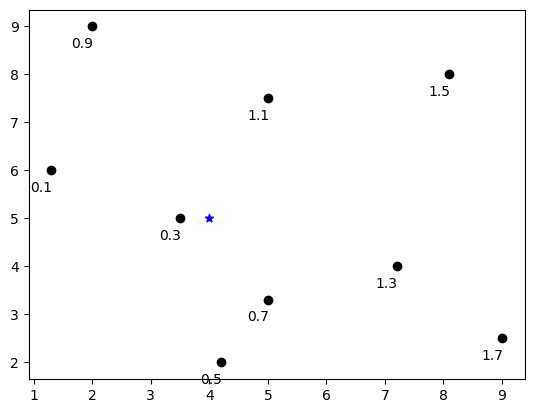

In [124]:
plt.scatter(X_train[:, 0], X_train[:, 1], color="black")        # 绘制训练数据的散点图
plt.scatter(data_new[0], data_new[1], color="b", marker="*")    # 绘制待预测的新数据点
for i in range(len(y_train)):      # 遍历所有训练数据的标签
    plt.annotate(
        y_train[i],            # 显示对应的类别标签
        xy=X_train[i],         # 标签对应的数据点坐标
        xytext=(-15, -15),     # 标签相对于数据点的偏移位置
        textcoords="offset points")   # 使用点作为偏移单位
plt.show()

## 1.计算新样本点与已知样本点的距离

In [125]:
for data in X_train:
    print(np.sqrt(np.sum((data - data_new) ** 2)))

2.879236009777594
0.5
3.006659275674582
1.9723082923316022
4.47213595499958
2.692582403567252
3.3526109228480423
5.080354318352215
5.5901699437494745


In [126]:
distances = [np.sqrt(np.sum((data - data_new) ** 2)) for data in X_train]
distances

[np.float64(2.879236009777594),
 np.float64(0.5),
 np.float64(3.006659275674582),
 np.float64(1.9723082923316022),
 np.float64(4.47213595499958),
 np.float64(2.692582403567252),
 np.float64(3.3526109228480423),
 np.float64(5.080354318352215),
 np.float64(5.5901699437494745)]

## 2.按距离排序

In [127]:
sort_index = np.argsort(distances)  # 按距离从小到大返回对应元素的索引
sort_index

array([1, 3, 5, 0, 2, 6, 4, 7, 8])

## 3.确定K值

In [128]:
k = 5

## 4.计算距离最近的k个点的均值

In [129]:
first_k = [y_train[i] for i in sort_index[:k]]  # 获取距离最近的K个样本的类别标签
np.mean(first_k)

np.float64(0.54)

## 5.scikit-learn中的KNN回归算法

In [130]:
from sklearn.neighbors import KNeighborsRegressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train);    # 使用训练集训练模型

In [131]:
result = knn_reg.predict(data_new.reshape(1, -1))  # 预测新样本的类别
result

array([0.54])

## 6.KNN回归（fetch_california_housing数据集）

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

In [133]:
housing = fetch_california_housing()
X = housing.data
y = housing.target
X.shape, y.shape

((20640, 8), (20640,))

In [134]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233)

In [136]:
from sklearn.neighbors import KNeighborsRegressor

In [137]:
knn_reg = KNeighborsRegressor(n_neighbors=5, weights="distance", p=2)
knn_reg.fit(X_train, y_train);

In [138]:
knn_reg.score(X_test, y_test)

0.15709075311665432

### 归一化

In [139]:
from sklearn.preprocessing import StandardScaler

In [140]:
standard_scaler = StandardScaler()  # 创建标准化处理器

In [141]:
standard_scaler.fit(X_train);  # 根据训练集计算均值和标准差

In [142]:
X_train = standard_scaler.transform(X_train)  # 对训练集进行标准化

In [143]:
X_test = standard_scaler.transform(X_test)  # 使用训练集的标准化参数处理测试集

In [144]:
knn_reg.fit(X_train, y_train);  # 使用标准化后的训练集训练模型

In [145]:
knn_reg.score(X_test, y_test)  # 计算模型在测试集上的决定系数 R²

0.6840653317471668